# 01 — Análise Exploratória de Dados

**Pergunta de negócio:** é possível prever, no momento do pedido, se um solicitante de cartão
de crédito vai se tornar um **mau pagador**?

Duas fontes de dados:

- `application_record.csv` — o cadastro de cada solicitante (perfil pessoal e financeiro);
- `credit_record.csv` — o histórico mensal de pagamento de quem já é cliente.

O alvo (`mau_pagador`) nasce do histórico: **1** se o cliente teve ao menos um mês com atraso
de **60 dias ou mais**. A construção e a justificativa do limiar estão no notebook 02; aqui
usamos a mesma função (`src.preprocessing.build_target`) para poder olhar os dados já rotulados.

Toda visualização tem um parágrafo de interpretação logo abaixo.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.config import TARGET
from src.data import load_application, load_credit
from src.preprocessing import build_features, build_target, check_missing, drop_duplicated_ids
from src.viz import COR_BOM, COR_MAU, aplicar_estilo, salvar

# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
aplicar_estilo()

In [2]:
app = load_application()
credit = load_credit()
print("application_record:", app.shape)
print("credit_record:     ", credit.shape)
app.head()

application_record: (438557, 18)
credit_record:      (1048575, 3)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


## 1. Visão geral

### 1.1 Cadastro dos solicitantes

In [3]:
app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [4]:
print("IDs únicos:", app["ID"].nunique(), "| IDs repetidos:", app["ID"].duplicated(keep=False).sum(), "linhas")
check_missing(app)

IDs únicos: 438510 | IDs repetidos: 94 linhas


,nulos,pct
OCCUPATION_TYPE,134203,30.6


In [5]:
app.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,438557.0,6.022176e+06,571637.023257,5008804.0,5609375.0,6047745.0,6456971.0,7999952.0
CNT_CHILDREN,438557.0,4.273903e-01,0.724882,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,438557.0,1.875243e+05,110086.853066,26100.0,121500.0,160780.5,225000.0,6750000.0
DAYS_BIRTH,438557.0,-1.599790e+04,4185.030007,-25201.0,-19483.0,-15630.0,-12514.0,-7489.0
DAYS_EMPLOYED,438557.0,6.056368e+04,138767.799647,-17531.0,-3103.0,-1467.0,-371.0,365243.0
FLAG_MOBIL,438557.0,1.000000e+00,0.000000,1.0,1.0,1.0,1.0,1.0
FLAG_WORK_PHONE,438557.0,2.061328e-01,0.404527,0.0,0.0,0.0,0.0,1.0
FLAG_PHONE,438557.0,2.877710e-01,0.452724,0.0,0.0,0.0,1.0,1.0
FLAG_EMAIL,438557.0,1.082071e-01,0.310642,0.0,0.0,0.0,0.0,1.0
CNT_FAM_MEMBERS,438557.0,2.194465e+00,0.897207,1.0,2.0,2.0,3.0,20.0


### 1.2 Histórico de crédito

In [6]:
credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [7]:
status = credit["STATUS"].value_counts().reindex(["X", "C", "0", "1", "2", "3", "4", "5"])
legenda_status = {
    "X": "sem uso no mês", "C": "quitado", "0": "1-29 dias de atraso", "1": "30-59 dias",
    "2": "60-89 dias", "3": "90-119 dias", "4": "120-149 dias", "5": "150+ dias / perda",
}
pd.DataFrame({"significado": legenda_status, "meses": status, "pct": (status / status.sum() * 100).round(2)})

,significado,meses,pct
X,sem uso no mês,209230,19.95
C,quitado,442031,42.16
0,1-29 dias de atraso,383120,36.54
1,30-59 dias,11090,1.06
2,60-89 dias,868,0.08
3,90-119 dias,320,0.03
4,120-149 dias,223,0.02
5,150+ dias / perda,1693,0.16


In [8]:
print("Clientes no histórico:", credit["ID"].nunique())
print("Meses de histórico por cliente:")
credit.groupby("ID").size().describe().round(1)

Clientes no histórico: 45985
Meses de histórico por cliente:


count    45985.0
mean        22.8
std         15.5
min          1.0
25%         10.0
50%         19.0
75%         34.0
max         61.0
dtype: float64

### 1.3 Junção das duas bases

In [9]:
alvo = build_target(credit)
app_limpo = drop_duplicated_ids(app)
df = build_features(app_limpo.merge(alvo, on="ID", how="inner"))

print("Solicitantes no cadastro (sem IDs repetidos):", len(app_limpo))
print("Clientes com histórico:                      ", len(alvo))
print("Presentes nas duas bases (base de trabalho):  ", len(df))
df.head()

Solicitantes no cadastro (sem IDs repetidos): 438463
Clientes com histórico:                       45985
Presentes nas duas bases (base de trabalho):   36457


,ID,FLAG_FEMININO,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,mau_pagador,idade_anos,aposentado_ou_sem_vinculo,anos_empregado,cadastro_inconsistente,renda_per_capita
0,5008804,0,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Nao informado,2.0,0,32.9,0,12.4,0,213750.0
1,5008805,0,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Nao informado,2.0,0,32.9,0,12.4,0,213750.0
2,5008806,0,1,1,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,2.0,0,58.8,0,3.1,0,56250.0
3,5008808,1,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,0,52.3,0,8.4,0,270000.0
4,5008809,1,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,0,52.3,0,8.4,0,270000.0


**Interpretação:**

- **Cadastro:** 438.557 linhas e 18 colunas. Só `OCCUPATION_TYPE` tem nulos (30,6%). Há 47 IDs
  repetidos (94 linhas) com dados diferentes entre si. Como não dá para saber qual linha
  corresponde ao histórico de crédito, esses IDs serão descartados.
- `FLAG_MOBIL` vale 1 em todas as linhas. Uma variável constante não ajuda a distinguir
  ninguém e será removida no notebook 02.
- `DAYS_EMPLOYED` chega a 365.243 dias (cerca de 1.000 anos). Isso é um código do sistema para
  aposentados ou pessoas sem vínculo, não um valor real. Foi convertido em uma variável
  sim/não (`aposentado_ou_sem_vinculo`), e o tempo de emprego dessas pessoas foi zerado.
- **Histórico:** 1.048.575 registros mensais de 45.985 clientes, com mediana de 19 meses por
  cliente. Atraso de 60 dias ou mais (STATUS 2 a 5) é raro: 0,29% dos meses.
- **Junção:** só **36.457** solicitantes estão nas duas bases. É essa a base de trabalho. Os
  outros ~402 mil pedidos não têm histórico, portanto não têm rótulo, e não servem para
  treinar um modelo supervisionado.

## 2. Distribuição das variáveis

`build_features` já converteu as colunas de dias em anos (`idade_anos`, `anos_empregado`) e
criou `renda_per_capita` e `aposentado_ou_sem_vinculo` (valor-código 365243 em `DAYS_EMPLOYED`).
Os detalhes ficam no notebook 02.

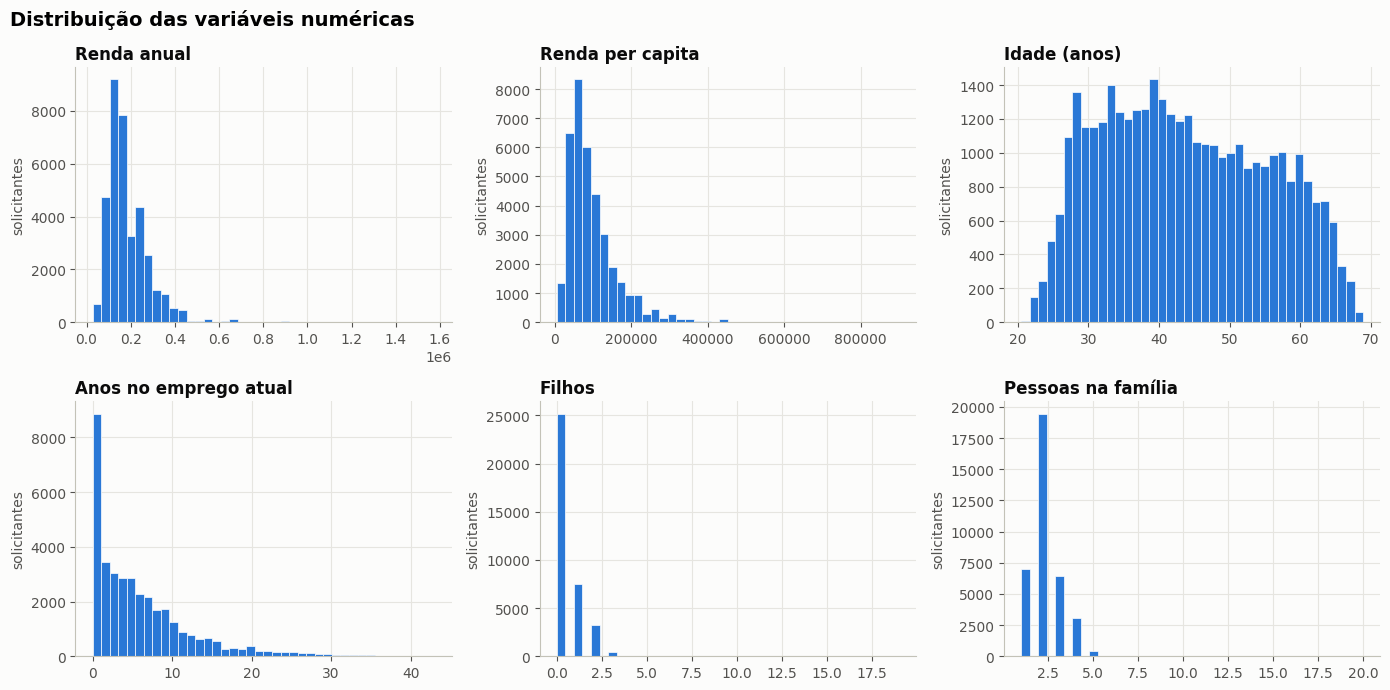

In [10]:
numericas = ["AMT_INCOME_TOTAL", "renda_per_capita", "idade_anos", "anos_empregado", "CNT_CHILDREN", "CNT_FAM_MEMBERS"]
rotulos = {
    "AMT_INCOME_TOTAL": "Renda anual", "renda_per_capita": "Renda per capita",
    "idade_anos": "Idade (anos)", "anos_empregado": "Anos no emprego atual",
    "CNT_CHILDREN": "Filhos", "CNT_FAM_MEMBERS": "Pessoas na família",
}

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, numericas):
    ax.hist(df[col], bins=40, color=COR_BOM, edgecolor="white", linewidth=0.5)
    ax.set_title(rotulos[col])
    ax.set_ylabel("solicitantes")
fig.suptitle("Distribuição das variáveis numéricas", x=0.01, ha="left", fontsize=14, fontweight="bold")
fig.tight_layout()
salvar(fig, "01_distribuicoes_numericas")
plt.show()

**Interpretação:**

- **Renda anual** e **renda per capita** têm forte assimetria à direita. A maioria fica entre
  100 e 250 mil por ano, com uma cauda longa que chega a 1,6 milhão. A renda aparece em valores
  "redondos" (picos em 135 mil, 180 mil, 225 mil), sinal de que é declarada pelo próprio
  solicitante e não comprovada.
- **Idade** se espalha de forma razoavelmente uniforme entre 25 e 65 anos (média de 44).
- **Anos no emprego** concentra muita gente em 0. Isso inclui os ~17% de aposentados ou sem
  vínculo cujo tempo foi zerado. Fora isso, a distribuição decai até cerca de 40 anos.
- **Filhos** e **pessoas na família** são contagens pequenas (0–2 filhos, 1–4 pessoas) com
  poucos casos extremos (até 19 filhos e 20 pessoas). Esses extremos são tratados na seção 4.

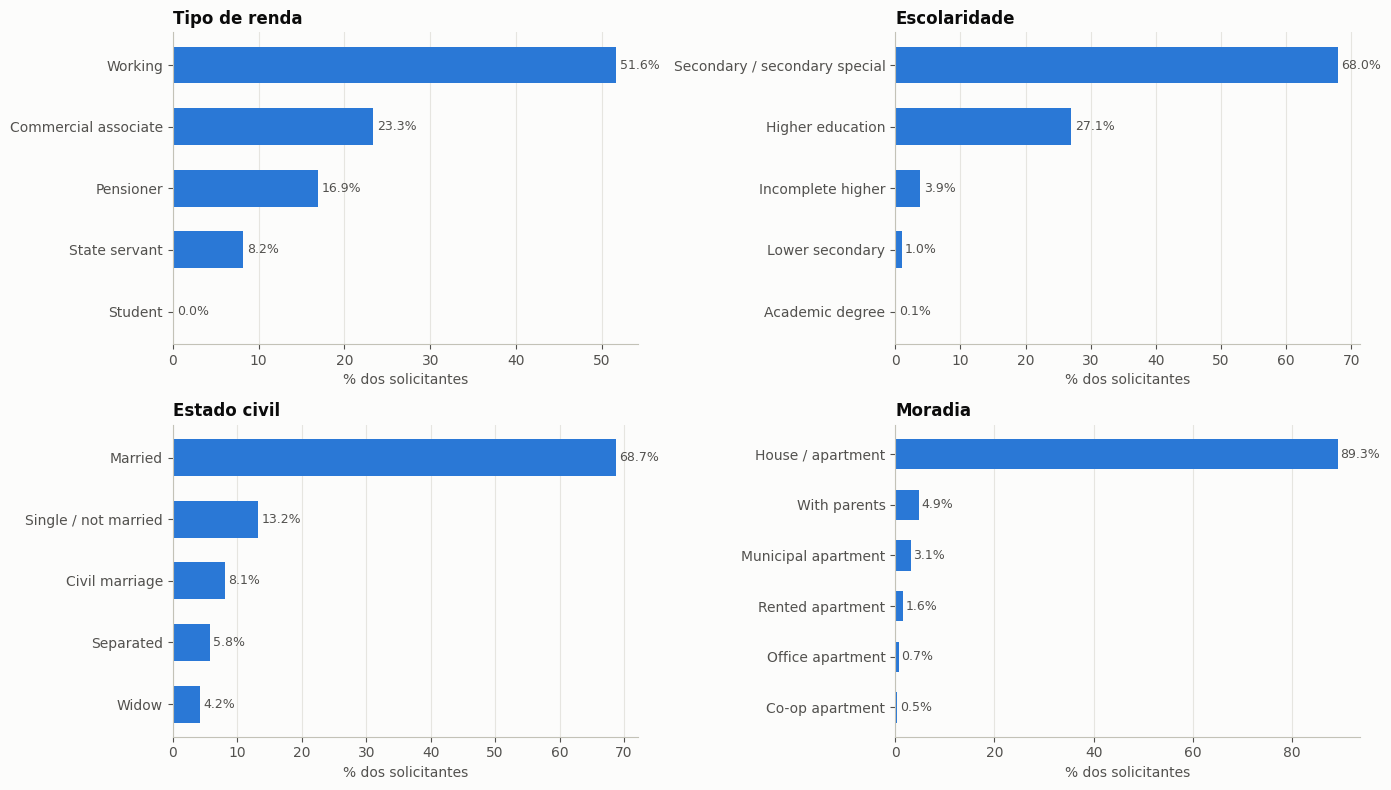

In [11]:
categoricas = ["NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE"]
titulos = {
    "NAME_INCOME_TYPE": "Tipo de renda", "NAME_EDUCATION_TYPE": "Escolaridade",
    "NAME_FAMILY_STATUS": "Estado civil", "NAME_HOUSING_TYPE": "Moradia",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flat, categoricas):
    cont = df[col].value_counts(normalize=True).sort_values() * 100
    ax.barh(cont.index, cont.values, color=COR_BOM, height=0.6)
    for y, v in enumerate(cont.values):
        ax.text(v + 0.5, y, f"{v:.1f}%", va="center", fontsize=9, color="#52514e")
    ax.set_title(titulos[col])
    ax.set_xlabel("% dos solicitantes")
    ax.grid(axis="y", visible=False)
fig.tight_layout()
salvar(fig, "01_distribuicoes_categoricas")
plt.show()

**Interpretação:**

- **Tipo de renda:** a maioria é assalariada (*Working*, 52%), seguida de autônomos/sócios
  (*Commercial associate*, 23%) e pensionistas (17%). Estudantes são raríssimos (11 pessoas).
- **Escolaridade:** 68% têm ensino médio. Só 32 pessoas têm pós-graduação (*Academic degree*),
  pouco demais para tirar qualquer conclusão sobre esse grupo.
- **Estado civil:** predominam casados (69%).
- **Moradia:** 89% moram em casa ou apartamento próprio (*House / apartment*). As demais
  categorias são pequenas.

Várias categorias têm poucos registros. Taxas calculadas nelas oscilam muito ao acaso, por isso
a seção 3.2 só mostra grupos com pelo menos 100 clientes.

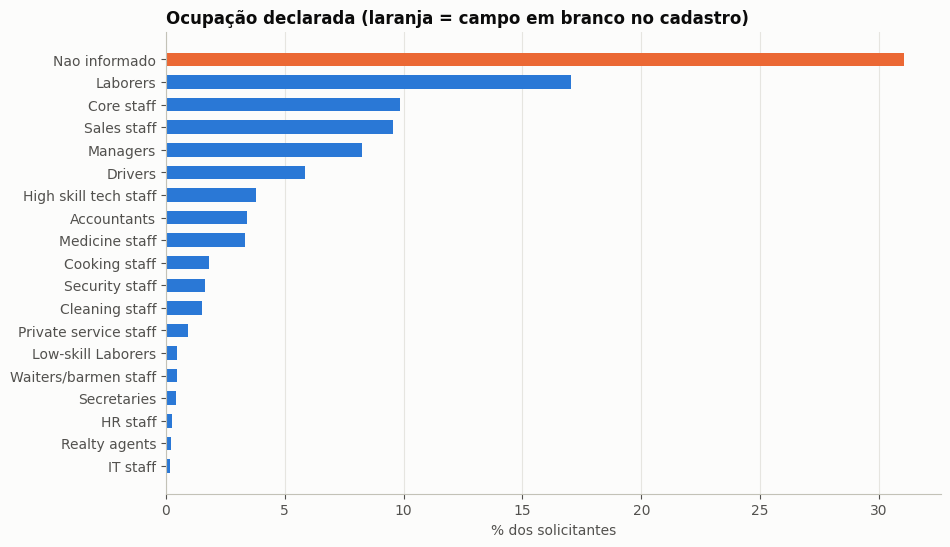

In [12]:
ocup = df["OCCUPATION_TYPE"].value_counts(normalize=True).sort_values() * 100
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(ocup.index, ocup.values, color=[COR_MAU if i == "Nao informado" else COR_BOM for i in ocup.index], height=0.6)
ax.set_title("Ocupação declarada (laranja = campo em branco no cadastro)")
ax.set_xlabel("% dos solicitantes")
ax.grid(axis="y", visible=False)
salvar(fig, "01_ocupacao")
plt.show()

**Interpretação:** em 31% dos cadastros a ocupação está em branco, o maior "grupo" de todos.
Excluir essas linhas descartaria um terço da base. Além disso, deixar o campo vazio pode ser um
comportamento informativo por si só. Por isso a ausência vira a categoria própria `Nao informado`.
Entre as ocupações preenchidas, *Laborers* (operários), *Core staff*, *Sales staff* e *Managers*
são as mais comuns.

## 3. Correlações

### 3.1 Entre as variáveis numéricas

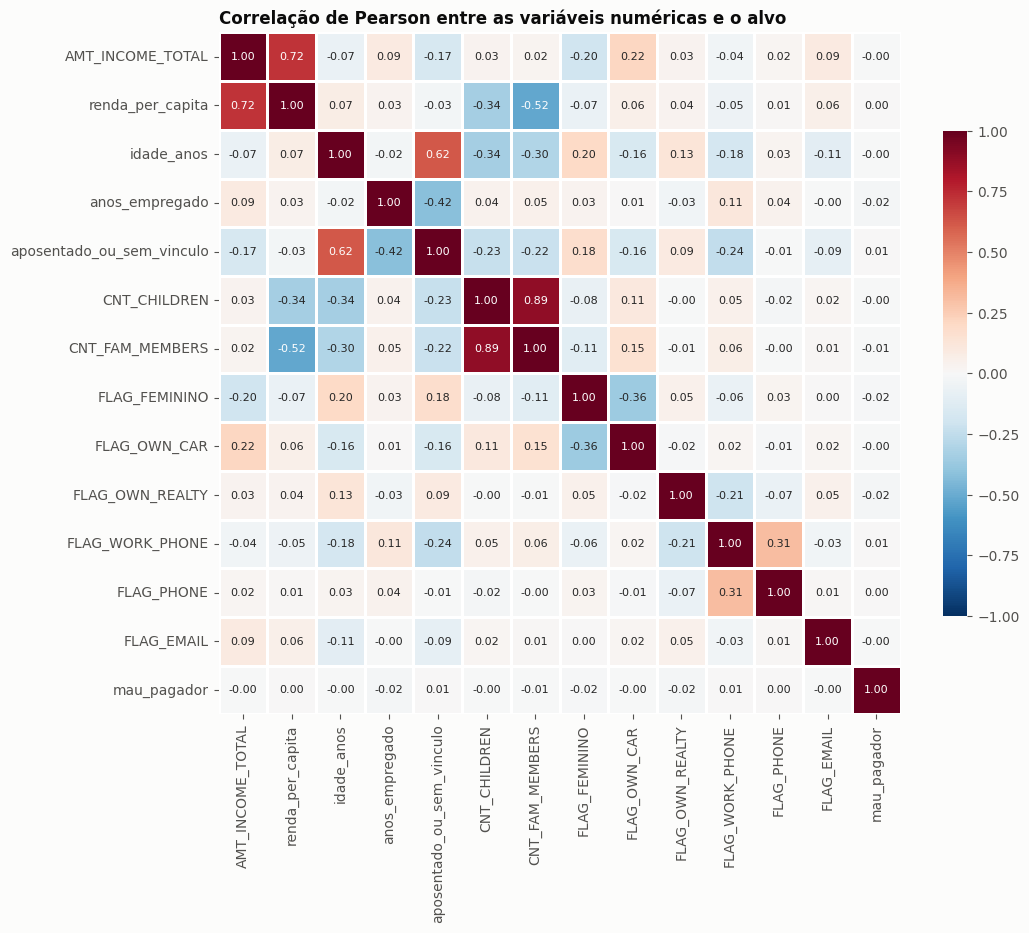

In [13]:
num_corr = ["AMT_INCOME_TOTAL", "renda_per_capita", "idade_anos", "anos_empregado",
            "aposentado_ou_sem_vinculo", "CNT_CHILDREN", "CNT_FAM_MEMBERS",
            "FLAG_FEMININO", "FLAG_OWN_CAR", "FLAG_OWN_REALTY",
            "FLAG_WORK_PHONE", "FLAG_PHONE", "FLAG_EMAIL", TARGET]
corr = df[num_corr].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size": 8}, linewidths=1, linecolor="white", square=True,
            cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Correlação de Pearson entre as variáveis numéricas e o alvo")
ax.grid(False)
salvar(fig, "01_correlacoes")
plt.show()

**Interpretação:**

- **Nenhuma variável numérica tem correlação linear relevante com `mau_pagador`.** Todos os
  valores ficam entre −0,02 e +0,01. Isso é coerente com o alvo raro (1,7%) e mostra que não
  existe um único fator que explique sozinho o risco. Se houver sinal, ele estará em combinações
  de variáveis e em relações não lineares, que é o caso de uso de modelos de árvore.
- **Redundâncias entre as próprias variáveis:**
  - `CNT_CHILDREN` × `CNT_FAM_MEMBERS` = **0,89**. Quase a mesma informação (família = filhos +
    adultos). Candidato a remoção na seleção de atributos.
  - `AMT_INCOME_TOTAL` × `renda_per_capita` = 0,72. Esperado, já que uma é derivada da outra.
    Ambas ficam por ora: a per capita traz a informação de "quantas pessoas a renda sustenta".
  - `idade_anos` × `aposentado_ou_sem_vinculo` = 0,62, e `anos_empregado` × `aposentado_ou_sem_vinculo`
    = −0,42. Também esperado: aposentados são mais velhos e têm tempo de emprego zerado.
  - `FLAG_FEMININO` × `FLAG_OWN_CAR` = −0,36. Na base, mulheres declaram ter carro com menos frequência.
  - `FLAG_WORK_PHONE` × `FLAG_PHONE` = 0,31: quem informa um telefone tende a informar o outro.
- As demais correlações ficam abaixo de |0,25|, ou seja, não há multicolinearidade grave além
  do par filhos × família.

### 3.2 Taxa de mau pagador por categoria

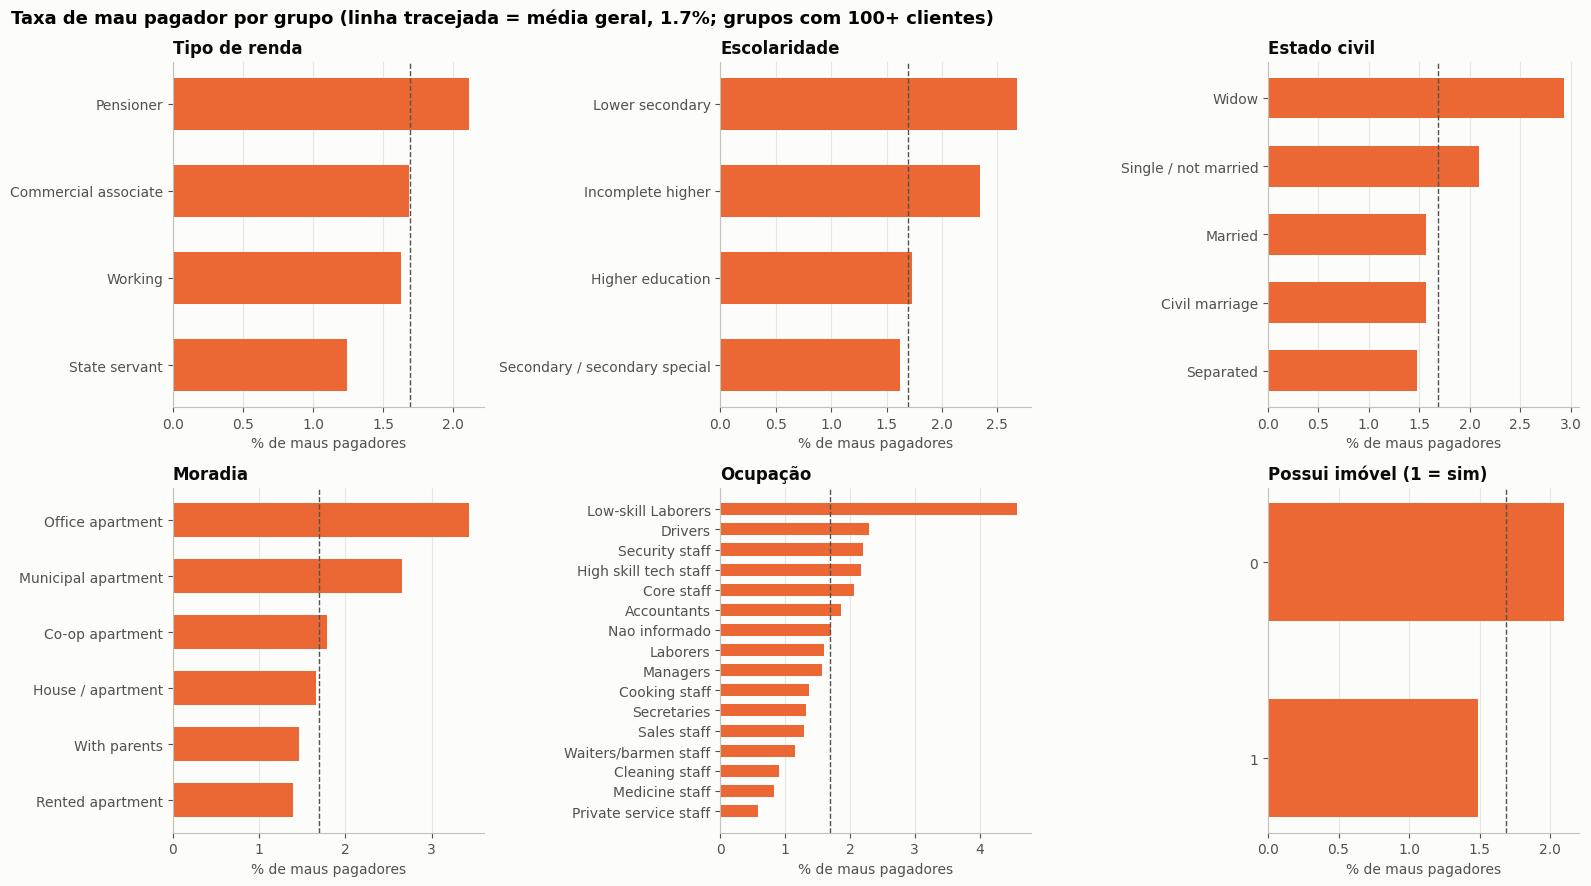

In [14]:
taxa_geral = df[TARGET].mean() * 100

def taxa_por(col, min_n=100):
    t = df.groupby(col)[TARGET].agg(taxa="mean", n="size")
    t["taxa"] *= 100
    return t[t["n"] >= min_n].sort_values("taxa")

titulos |= {"OCCUPATION_TYPE": "Ocupação", "FLAG_OWN_REALTY": "Possui imóvel (1 = sim)"}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, categoricas + ["OCCUPATION_TYPE", "FLAG_OWN_REALTY"]):
    t = taxa_por(col)
    ax.barh(t.index.astype(str), t["taxa"], color=COR_MAU, height=0.6)
    ax.axvline(taxa_geral, color="#52514e", linestyle="--", linewidth=1)
    ax.set_title(titulos[col])
    ax.set_xlabel("% de maus pagadores")
    ax.grid(axis="y", visible=False)
fig.suptitle(f"Taxa de mau pagador por grupo (linha tracejada = média geral, {taxa_geral:.1f}%; grupos com 100+ clientes)",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
salvar(fig, "01_taxa_mau_por_categoria")
plt.show()

**Interpretação** (média geral de 1,7%):

- **Tipo de renda:** pensionistas têm a maior taxa (2,1%) e servidores públicos (*State servant*)
  a menor (1,2%). Renda estável e garantida reduz o risco.
- **Escolaridade:** quanto menor a escolaridade, maior a taxa. Ensino fundamental (*Lower
  secondary*) fica em 2,7% e superior incompleto em 2,3%, contra cerca de 1,6–1,7% nos demais.
- **Estado civil:** viúvos (2,9%) e solteiros (2,1%) ficam acima da média. Casados e separados
  ficam abaixo.
- **Moradia:** quem mora em apartamento funcional (*Office apartment*, 3,4%) ou municipal
  (2,7%) tem risco maior. Quem mora de aluguel ou com os pais fica abaixo da média.
- **Ocupação:** trabalhadores de baixa qualificação (*Low-skill Laborers*) têm 4,6%, quase
  3 vezes a média. Equipe médica, de limpeza e de serviços privados ficam abaixo de 1%.
- **Imóvel próprio:** quem não tem imóvel tem 2,1% de maus, contra 1,5% de quem tem.

As diferenças existem, mas são **modestas em termos absolutos**, de 1 a 3 pontos percentuais.
Vários grupos de alto risco são pequenos (ex.: 175 *Low-skill Laborers*, 262 em *Office
apartment*), então essas taxas têm margem de erro alta. O modelo precisará combinar vários
desses sinais fracos.

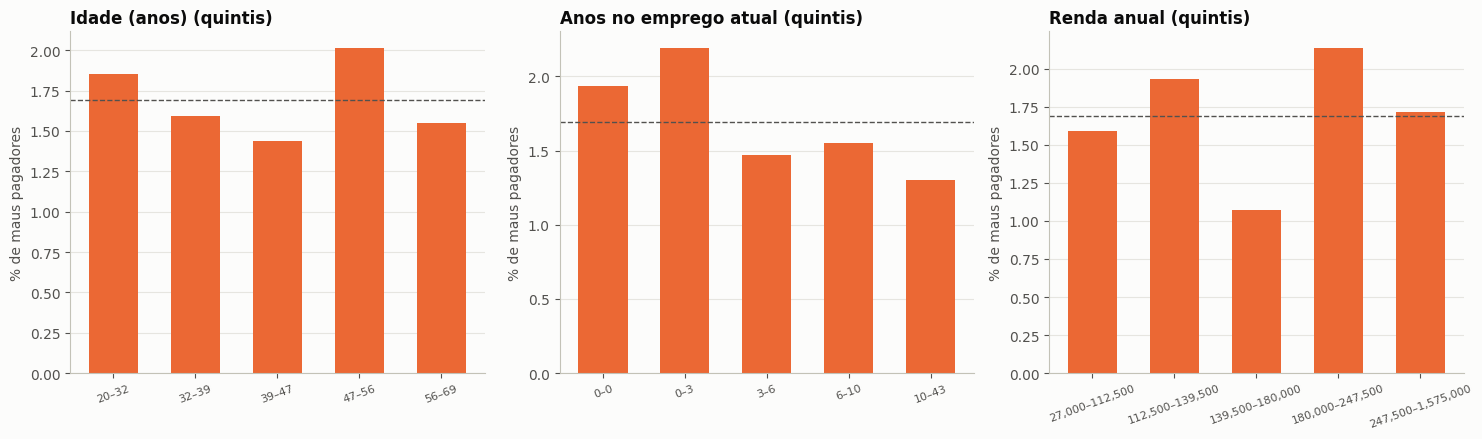

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ["idade_anos", "anos_empregado", "AMT_INCOME_TOTAL"]):
    faixas = pd.qcut(df[col].rank(method="first"), 5, labels=[f"Q{i}" for i in range(1, 6)])
    t = df.groupby(faixas, observed=True)[TARGET].mean() * 100
    lim = df.groupby(faixas, observed=True)[col].agg(["min", "max"])
    ax.bar([f"{a:,.0f}–{b:,.0f}" for a, b in lim.values], t.values, color=COR_MAU, width=0.6)
    ax.axhline(taxa_geral, color="#52514e", linestyle="--", linewidth=1)
    ax.set_title(rotulos[col] + " (quintis)")
    ax.set_ylabel("% de maus pagadores")
    ax.tick_params(axis="x", labelsize=8, rotation=20)
    ax.grid(axis="x", visible=False)
fig.tight_layout()
salvar(fig, "01_taxa_mau_por_faixa")
plt.show()

**Interpretação:**

- **Idade:** não há tendência clara. A faixa de 47–56 anos tem a maior taxa (2,0%) e a de 39–47
  a menor (1,4%). A relação não é linear, o que reforça o uso de modelos de árvore.
- **Tempo de emprego:** este é o padrão mais consistente. A taxa cai de cerca de 2% em quem tem
  até 3 anos de casa para 1,3% em quem tem mais de 10. A primeira faixa ("0–0") é composta
  majoritariamente por aposentados/sem vínculo.
- **Renda anual:** não é monotônica. A faixa intermediária (139–180 mil) tem a menor taxa (1,1%),
  e a seguinte (180–247 mil) a maior (2,1%). **Renda alta não garante bom pagamento** nesta base.

## 4. Outliers

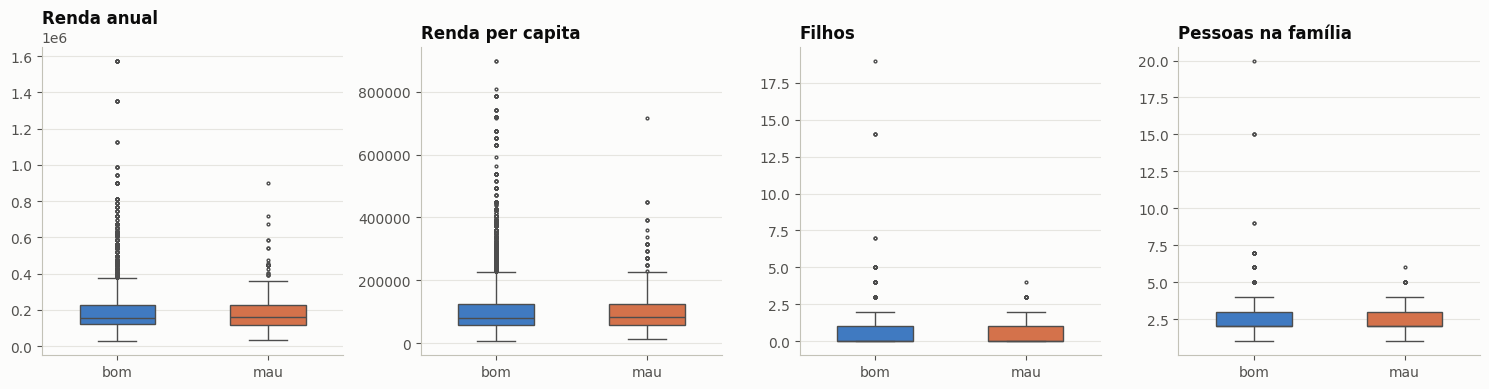

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, col in zip(axes, ["AMT_INCOME_TOTAL", "renda_per_capita", "CNT_CHILDREN", "CNT_FAM_MEMBERS"]):
    sns.boxplot(data=df, x=TARGET, y=col, hue=TARGET, palette=[COR_BOM, COR_MAU], legend=False,
                width=0.5, linewidth=1, fliersize=2, ax=ax)
    ax.set_title(rotulos[col])
    ax.set_xticks([0, 1], ["bom", "mau"])
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.tight_layout()
salvar(fig, "01_outliers")
plt.show()

In [17]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    lim = q3 + 1.5 * (q3 - q1)
    return pd.Series({"limite_superior": lim, "qtd_acima": (s > lim).sum(), "pct": round((s > lim).mean() * 100, 2), "maximo": s.max()})

pd.DataFrame({c: iqr_outliers(df[c]) for c in ["AMT_INCOME_TOTAL", "renda_per_capita", "CNT_CHILDREN", "CNT_FAM_MEMBERS"]}).T

,limite_superior,qtd_acima,pct,maximo
AMT_INCOME_TOTAL,380250.0,1529.0,4.19,1575000.0
renda_per_capita,225000.0,1750.0,4.80,900000.0
CNT_CHILDREN,2.5,508.0,1.39,19.0
CNT_FAM_MEMBERS,4.5,480.0,1.32,20.0


**Interpretação e decisão:**

- **Renda:** 4,2% dos solicitantes estão acima do limite estatístico (1,5 × IQR), com máximo de
  1,575 milhão. São rendas altas, mas plausíveis, e não erros de digitação. **Decisão: manter.**
  Os modelos de árvore não são sensíveis à escala. Na regressão logística, a padronização limita
  o impacto, e não há evidência de que esses clientes se comportem de forma diferente (os
  boxplots de bons e maus são praticamente iguais).
- **Filhos / família:** pouco mais de 1% passa do limite. Os casos extremos (14 e 19 filhos,
  20 pessoas) somam só 4 registros, todos bons pagadores. **Decisão: manter**, pelo mesmo motivo.
  Na seleção de atributos `CNT_CHILDREN` sai por redundância com `CNT_FAM_MEMBERS`, então
  só um dos dois chega ao modelo.

Os boxplots de bons e maus pagadores praticamente se sobrepõem em todas as variáveis.
Nenhuma delas sozinha separa as classes, o que confirma a leitura das correlações.

## 5. Balanceamento de classes

mau_pagador
bom pagador    35841
mau pagador      616
Name: count, dtype: int64
mau_pagador
bom pagador    98.31
mau pagador     1.69
Name: count, dtype: float64


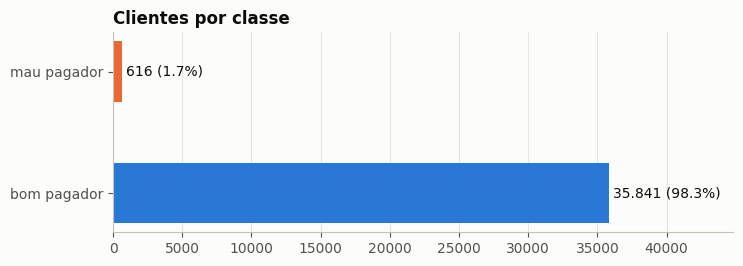

In [18]:
bal = df[TARGET].value_counts().rename({0: "bom pagador", 1: "mau pagador"})
print(bal)
print((bal / bal.sum() * 100).round(2))

fig, ax = plt.subplots(figsize=(8, 2.6))
ax.barh(bal.index, bal.values, color=[COR_BOM, COR_MAU], height=0.5)
for y, v in enumerate(bal.values):
    ax.text(v + 300, y, f"{v:,} ({v / bal.sum():.1%})".replace(",", "."), va="center", color="#0b0b0b")
ax.set_title("Clientes por classe")
ax.set_xlim(0, bal.max() * 1.25)
ax.grid(axis="y", visible=False)
salvar(fig, "01_balanceamento")
plt.show()

**Interpretação:** apenas **616 de 36.457 clientes (1,69%)** são maus pagadores, uma proporção
de cerca de 1 para 58. Isso tem três consequências diretas:

1. **Acurácia não serve como métrica.** Um "modelo" que aprova todo mundo acerta 98,3% e não
   identifica nenhum mau pagador.
2. **Métricas priorizadas:** o objetivo é encontrar os maus pagadores, então o foco é o
   **recall** da classe mau pagador e a **área sob a curva precisão-recall (PR-AUC)**, que mede a
   qualidade da ordenação de risco quando a classe positiva é rara. A AUC-ROC, a precisão e o F1
   também serão reportados.
3. **Treino e validação:** os modelos usarão `class_weight="balanced"`, que dá peso maior aos
   poucos exemplos de mau pagador. Os splits serão estratificados para manter 1,7% de maus em
   todos os conjuntos.

### 5.1 Perfis repetidos

O dataset original é conhecido por conter a mesma pessoa cadastrada com IDs diferentes.
Isso importa para a validação: se o mesmo perfil cair no treino e no teste, o modelo é
avaliado em clientes que já "viu".

In [19]:
atributos = [c for c in df.columns if c not in ("ID", TARGET)]
perfis = df.groupby(atributos, dropna=False)[TARGET].agg(["size", "nunique"])
print("Linhas na base:                   ", len(df))
print("Perfis distintos:                 ", len(perfis))
print("Linhas que repetem outro perfil:  ", len(df) - len(perfis))
print("Perfis com rótulos conflitantes:  ", (perfis["nunique"] > 1).sum())
perfis["size"].describe().round(1)

Linhas na base:                    36457
Perfis distintos:                  9691
Linhas que repetem outro perfil:   26766
Perfis com rótulos conflitantes:   271


count    9691.0
mean        3.8
std         3.4
min         1.0
25%         1.0
50%         3.0
75%         5.0
max        51.0
Name: size, dtype: float64

**Interpretação (ponto crítico para a modelagem):**

- Das 36.457 linhas, há só **9.691 perfis distintos**. **26.766 linhas (73%) repetem
  exatamente** os atributos de outra linha e diferem apenas no ID. Cada perfil aparece em
  média 3,8 vezes (até 51). O mais provável é que seja o mesmo cliente com várias contas ou
  vários pedidos.
- Em **271 perfis** o mesmo conjunto de atributos aparece com rótulos diferentes (bom em um ID e
  mau em outro). Nenhum modelo baseado apenas no cadastro consegue acertar esses casos.
- **Consequência:** numa divisão aleatória de treino e teste, cópias do mesmo perfil caem dos
  dois lados. O modelo pode "decorar" o perfil e parecer muito melhor do que é com clientes
  realmente novos. Esse risco precisa ser tratado na validação (notebooks 02 e 03).

## 6. Síntese da EDA

**A história que os dados contam:**

1. **O banco tem um universo grande de pedidos, mas pouca informação sobre o desfecho.** Dos
   438 mil cadastros, apenas 36 mil (8%) têm histórico de pagamento. É sobre eles que o modelo
   aprende.
2. **Inadimplência séria é rara: 1,7%.** Por isso a acurácia é inútil e o foco vai para a capacidade
   de **encontrar os poucos maus pagadores** (recall e PR-AUC).
3. **Não existe um único fator decisivo.** Nenhuma variável tem correlação relevante com o alvo.
   O risco aparece em **sinais fracos que se somam**: pouco tempo no emprego, baixa escolaridade,
   ocupações de baixa qualificação, não ter imóvel próprio, ser viúvo ou solteiro e morar em
   apartamento funcional ou municipal. Cada um eleva o risco em 1 a 3 pontos percentuais.
4. **Renda declarada não é proteção.** A taxa de mau pagador não cai de forma consistente com a
   renda.
5. **Qualidade dos dados:** ocupação em branco em 31% dos cadastros (vira uma categoria própria),
   código artificial para aposentados em `DAYS_EMPLOYED`, uma coluna constante e, principalmente,
   **73% das linhas repetem o perfil de outra**. Isso exige cuidado na validação para não
   superestimar o desempenho.

**Expectativa realista:** com sinais tão fracos, o modelo não vai "adivinhar" quem será mau
pagador. O valor dele está em **ordenar os solicitantes por risco**, para que a política de
crédito concentre a análise ou a recusa na faixa mais arriscada.